In [1]:

from skimage.io import imread, imsave, imshow
from src.python.data.generate_pathloss_images import calculate_PL_mat,calculate_PL_mat_parallel
import numpy as np
import matplotlib.pyplot as plt

In [2]:
WIDTH = 256
HEIGHT = 256

In [3]:
BLACK_PL_PATH = './data/base/out/no_obstacle.png'
BLACK_PATH = './data/base/black.png'

In [4]:

IMAGE_PATH = './data/ter_wrap/teren_007.png'
CONTROL_PATH = './data/PL_wrap_orig/teren_007.png'

In [5]:
center_y, center_x = WIDTH // 2, HEIGHT // 2

In [6]:
image = imread(IMAGE_PATH)
black = imread(BLACK_PATH)
control = imread(CONTROL_PATH)

In [7]:
image_pl = calculate_PL_mat_parallel(image)

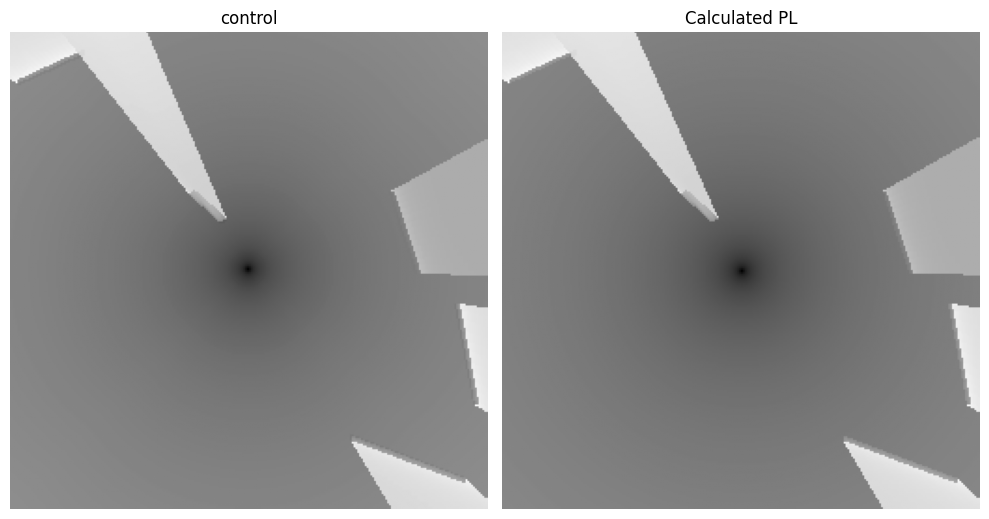

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 10))

axs[0].imshow(control, cmap='gray')
axs[0].set_title('Control')
axs[0].axis('off')

axs[1].imshow(image_pl, cmap='gray')
axs[1].set_title('Calculated PL')
axs[1].axis('off')

plt.tight_layout()
plt.show()

In [54]:
black_pl = calculate_PL_mat_parallel(black)
# black_pl = imread(BLACK_PL_PATH)

In [59]:
imsave(BLACK_PL_PATH, black_pl.astype(np.uint8))
TEST_PATH = './data/test.png'
imsave(TEST_PATH, image_pl.astype(np.uint8))

In [60]:
image_pl=imread(TEST_PATH)
blck_pl=imread(BLACK_PL_PATH)

In [61]:
def normalize_by_black(pl, black_pl):
    # Calculate the offset needed to match the center value of black_pl
    offset = black_pl[center_y, center_x] - pl[center_y, center_x]

    # Apply the offset to image_pl
    return (pl + offset).astype(np.uint8)

image_pl_center_normalized = normalize_by_black(image_pl, black_pl)

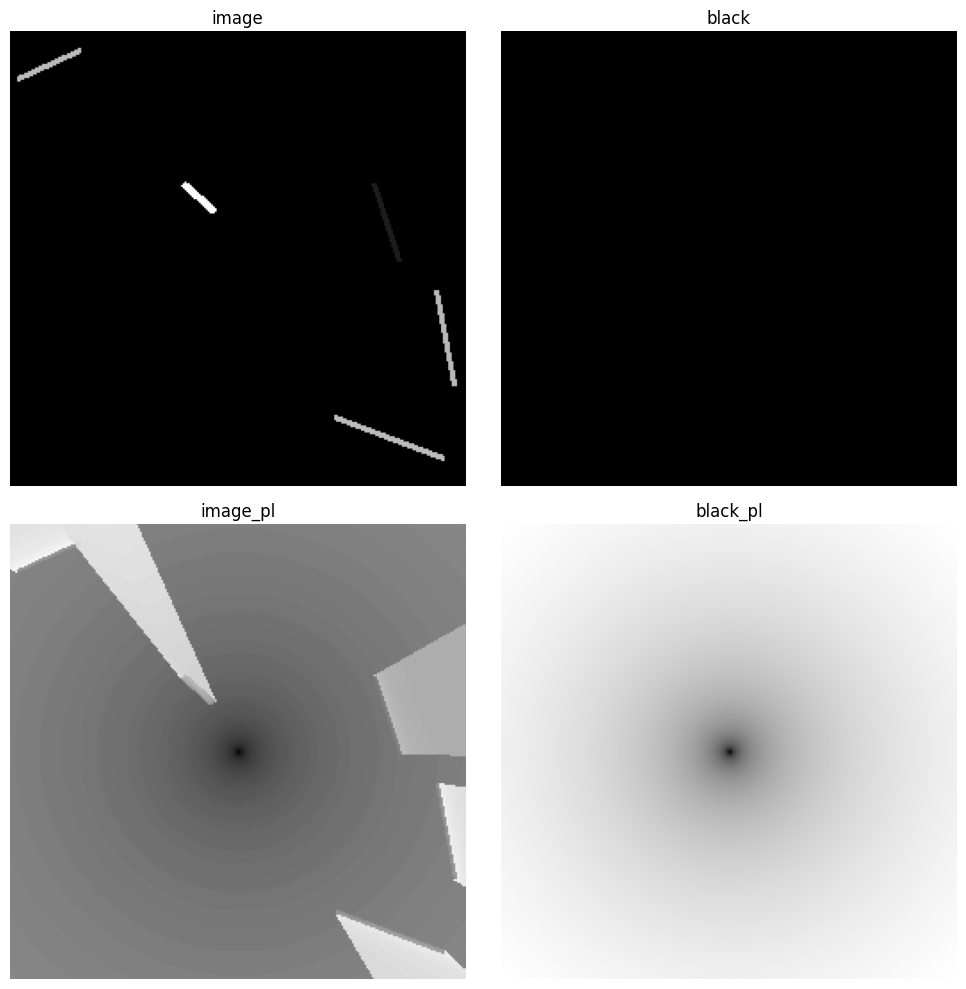

In [62]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0, 0].imshow(image, cmap='gray')
axs[0, 0].set_title('image')
axs[0, 0].axis('off')

axs[0, 1].imshow(black, cmap='gray')
axs[0, 1].set_title('black')
axs[0, 1].axis('off')

axs[1, 0].imshow(image_pl_center_normalized, cmap='gray')
axs[1, 0].set_title('image_pl')
axs[1, 0].axis('off')

axs[1, 1].imshow(black_pl, cmap='gray')
axs[1, 1].set_title('black_pl')
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [63]:
static_image_pl = image_pl_center_normalized - black_pl

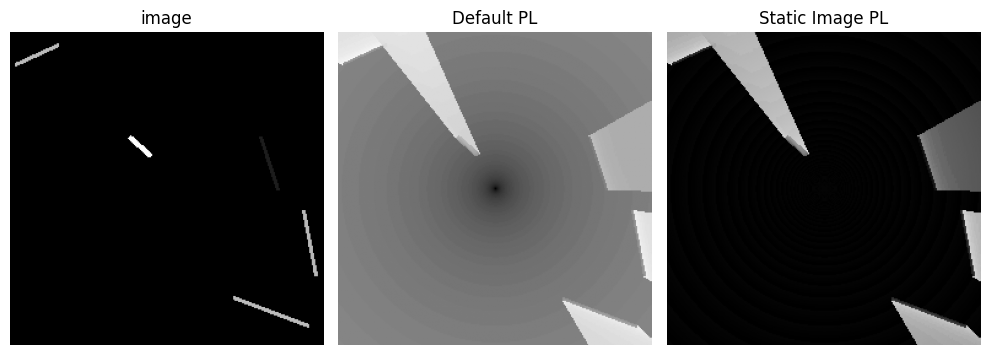

In [64]:
fig, axs = plt.subplots(1, 3, figsize=(10, 10))

axs[0].imshow(image, cmap='gray')
axs[0].set_title('image')
axs[0].axis('off')

axs[1].imshow(image_pl, cmap='gray')
axs[1].set_title('Default PL')
axs[1].axis('off')

axs[2].imshow(static_image_pl, cmap='gray')
axs[2].set_title('Static Image PL')
axs[2].axis('off')

plt.tight_layout()
plt.show()

